# Intro to superpixels
Quick presentation of most known superpixel generation methods along with short explanation.

Most of the notes are based on this article from skiimage docx: https://scikit-image.org/docs/stable/auto_examples/segmentation/plot_segmentations.html

In [2]:
# Imports
import os
import PIL.Image
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries



## Sample data

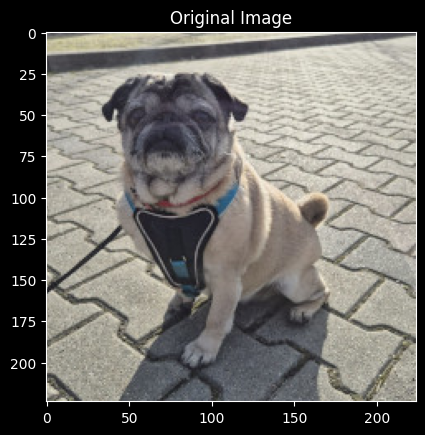

In [3]:
path = os.path.join('assets', 'MyPug.jpg')
img = np.array(PIL.Image.open(path))

plt.imshow(img)
plt.title('Original Image')
plt.show()

# Squares Mask
Mostly used as reference, simple idea of splitting image into squares.

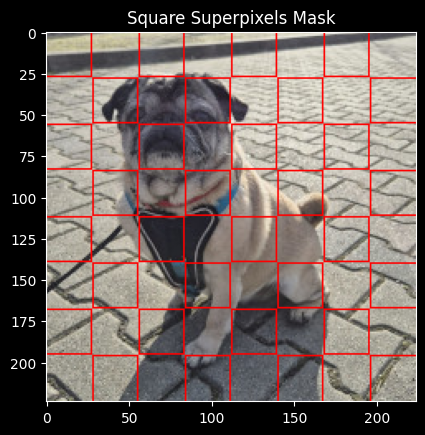

In [4]:
from skimage.segmentation import checkerboard_level_set

sq_mask = checkerboard_level_set(img.shape[0:2], square_size=28)
sq_img = mark_boundaries(img, sq_mask,color=(1,0,0))

plt.imshow(sq_img)
plt.title('Square Superpixels Mask')
plt.show()

# SLIC (Simple Linear Iterative Clustering)
This algorithm simply performs K-means in the 5d space of color information and image location and is therefore closely related to quickshift (Later).

Read more: https://ieeexplore.ieee.org/abstract/document/6205760?casa_token=ozvO8039WVQAAAAA:mzzSf1k8Anv0vusD8hIMHW0pq7wQgEWQpOIiyHwwW147iBq0KbWZON11kpmMEAuYWIJSwY9_lwo

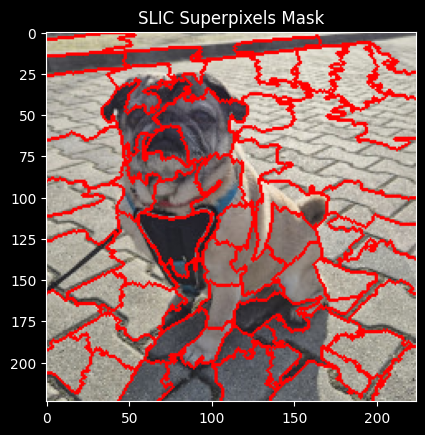

In [5]:
from skimage.segmentation import slic
slic_mask = slic(img)
slic_img = mark_boundaries(img/255, slic_mask, color=(1,0,0))
plt.imshow(slic_img)
plt.title('SLIC Superpixels Mask')
plt.show()

# Quick Shift
The algorithm is based in kernelized mean-shift approximation.
It belongs to the family of local mode-seeking algorithms and is applied to the 5D space consisting of color information and image location.
Simply it creates clusters of neighborhood pixels based on their similarity.

Read More: https://link.springer.com/chapter/10.1007/978-3-540-88693-8_52

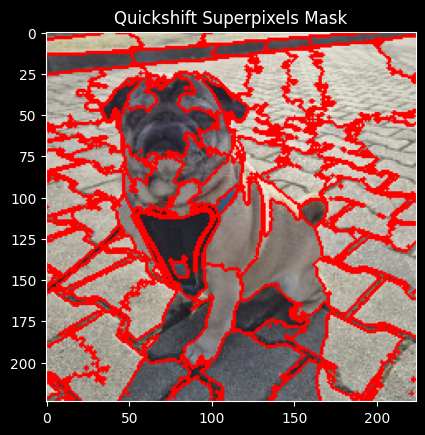

In [6]:
from skimage.segmentation import quickshift
qs_mask = quickshift(img)
qs_img = mark_boundaries(img/255.0, qs_mask, color=(1,0,0))
plt.imshow(qs_img)
plt.title('Quickshift Superpixels Mask')
plt.show()

# Felzenszwalb’s algorithm
Graph based algorithm. First, it creates centers of clusters based on `size` parameter, then it assigns pixel to the nearest (in terms of color and location) cluster center.

Read More: https://link.springer.com/article/10.1023/B:VISI.0000022288.19776.77

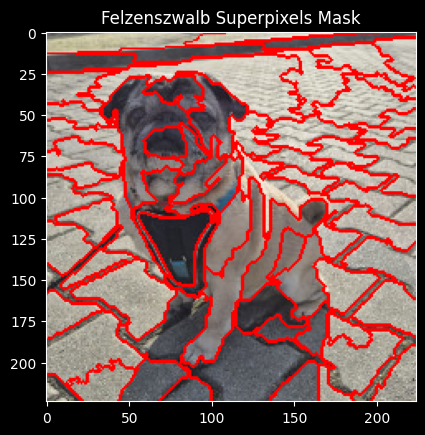

In [7]:
from skimage.segmentation import felzenszwalb
flb_mask = felzenszwalb(img, min_size=14*14)
flb_img = mark_boundaries(img/255, flb_mask, color=(1,0,0))
plt.imshow(flb_img)
plt.title('Felzenszwalb Superpixels Mask')
plt.show()

# Entropy as measure
Entropy is a measure of information. It describes average level of information or uncertainty related with variable.

In image analysis we calculate entropy treating greyscale intensity as an information. The more noisy is a cluster the more information is associated with it.

Read more: https://en.wikipedia.org/wiki/Entropy_(information_theory)

## Calculating Entropy Maps and Mean Entropy of superpixels function

In [8]:
import numpy as np
from skimage.measure import regionprops

def calculate_superpixel_entropy(img, segments):
    # Ensure image is grayscale for entropy calculation
    if len(img.shape) == 3:
        # Simple luminance conversion if RGB
        img = 0.2126 * img[:,:,0] + 0.7152 * img[:,:,1] + 0.0722 * img[:,:,2]

    # Convert image to 8-bit if it isn't already (standard for entropy)
    img_uint8 = (img - img.min()) / (img.max() - img.min()) * 255
    img_uint8 = img_uint8.astype(np.uint8)

    # Initialize the output map
    entropy_map = np.zeros(img.shape, dtype=np.float64)

    # Iterate through each superpixel
    regions = regionprops(segments)

    for props in regions:
        # Get the coordinates of pixels in this superpixel
        coords = props.coords

        # Extract pixel values for this specific superpixel
        pixel_values = img_uint8[coords[:, 0], coords[:, 1]]

        # Calculate Shannon entropy
        # hist returns the counts of each intensity value
        hist, _ = np.histogram(pixel_values, bins=256, range=(0, 256), density=True)

        # Remove zeros to avoid log(0)
        hist = hist[hist > 0]
        sp_entropy = -np.sum(hist * np.log2(hist))

        # Assign the entropy value to all pixels in this segment
        entropy_map[coords[:, 0], coords[:, 1]] = sp_entropy
        mean_entropy = np.mean(entropy_map)

    return entropy_map, mean_entropy

def show_entropy_map(img, mask, title="Entropy Map"):
    map, mean = calculate_superpixel_entropy(img, mask)
    plt.imshow(map)
    plt.title(title)
    plt.colorbar()
    plt.show()

    mean = float(mean)

    return mean

## Entropy for Square Clustering

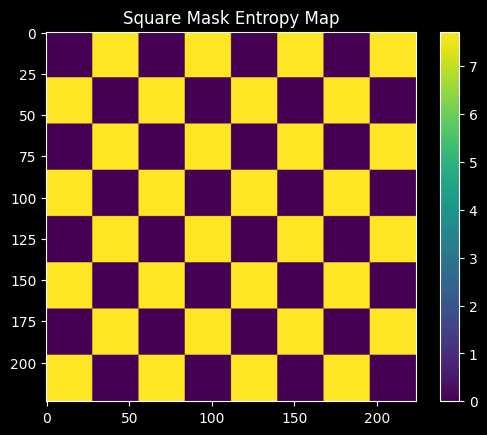

3.8611589956087053

In [9]:
show_entropy_map(img, sq_mask, title='Square Mask Entropy Map')

## Entropy for SLIC

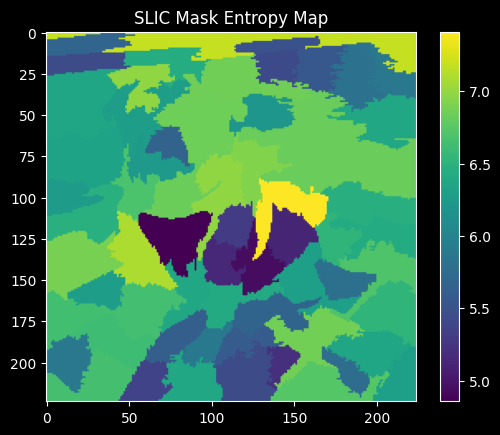

6.357548212974075

In [10]:
show_entropy_map(img, slic_mask, title='SLIC Mask Entropy Map')

## Entropy of Quickshift mask

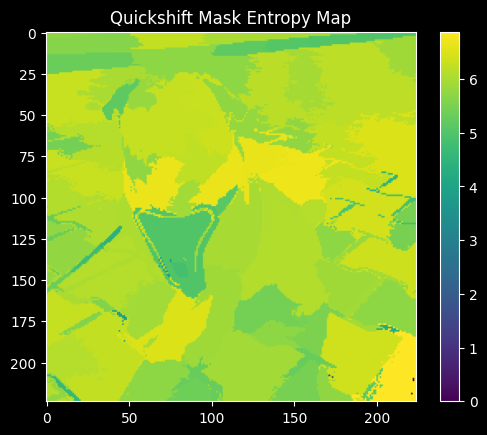

6.025496805058403

In [11]:
show_entropy_map(img, qs_mask, title='Quickshift Mask Entropy Map')

## Entropy for Felzenszwalb’s algorithm


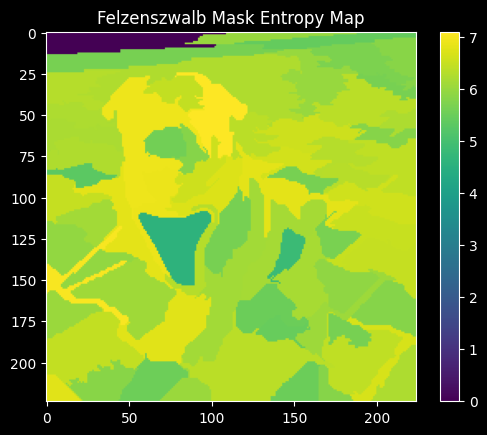

6.058029282128224

In [12]:
show_entropy_map(img, flb_mask, title='Felzenszwalb Mask Entropy Map')